- Learning with the MSELoss seems almost impossible
- KLDiv loss seems to help learning process though there are no results yet
- GAN does not care about loss and still does not work even though it seems to be learning

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_dir = "..\\data\\FJ\\FI01X1\\FI01X1_ch"

dataset_dir = Path(data_dir)
files = sorted(dataset_dir.glob("*.npz"))
if not files:
    raise RuntimeError("No .npz files found")

In [3]:
sample = np.load(files[0])

In [4]:
dataset = []
for f in files:
    sample = np.load(f)
    dataset.append(sample['values'])
print(len(dataset))

620


In [5]:
point_dim = len(dataset[0])

In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
dataset = scaler.fit_transform(dataset)
dataset = [scaler.fit_transform(h.reshape(-1, 1)).flatten() for h in dataset]

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [8]:
t = torch.rand(20)
x = nn.Linear(20, 40)(t)
print(F.relu(x))

tensor([0.1449, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.4567, 0.0000, 0.3482,
        0.4991, 0.4512, 0.0000, 0.2738, 0.0000, 0.0000, 0.0000, 0.1108, 0.0261,
        0.4234, 0.5403, 0.4643, 0.5464, 0.0671, 0.1815, 0.0826, 0.0000, 0.0938,
        0.0000, 0.3622, 0.0256, 0.0000, 0.0000, 0.3393, 0.0000, 0.0000, 0.5070,
        0.0000, 0.0000, 0.0000, 0.0000], grad_fn=<ReluBackward0>)


In [9]:
pt = dataset[0]
pt = torch.tensor(pt).float()

pt = pt.reshape(1, 1, 96)

In [93]:
# DISCRIMINATOR testing

conv1 = nn.Conv1d(in_channels=1, out_channels=4, kernel_size=4, stride=2)
conv2 = nn.Conv1d(in_channels=4, out_channels=8, kernel_size=4, stride=2)
conv3 = nn.Conv1d(in_channels=8, out_channels=16, kernel_size=4, stride=2)
torch.flatten(conv3(conv2(conv1(pt)))).shape

torch.Size([160])

In [101]:
# GENERATOR testing

tns = torch.tensor([np.random.random(1) for _ in range(20)]).float()
tns = tns.reshape(1,1,20)

conv1 = nn.ConvTranspose1d(in_channels=1, out_channels=1, kernel_size=4, stride=2)
conv2 = nn.ConvTranspose1d(in_channels=1, out_channels=1, kernel_size=4, stride=2)
conv1(conv2(tns)).shape

torch.Size([1, 1, 86])

In [102]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        # self.conv1 = nn.Conv1d(in_channels=1, out_channels=3, kernel_size=3, stride=2)
        # self.conv1 = nn.Conv1d(in_channels=3, out_channels=9, kernel_size=3, stride=2)
        # self.conv1 = nn.Conv1d(in_channels=9, out_channels=16, kernel_size=3, stride=2)
        # self.fc = nn.Linear()
        self.conv1 = nn.ConvTranspose1d(in_channels=1, out_channels=1, kernel_size=4, stride=2)
        self.conv2 = nn.ConvTranspose1d(in_channels=1, out_channels=1, kernel_size=4, stride=2)
        self.fc1 = nn.Linear(86, 90)
        self.fc2 = nn.Linear(90, 96)
        
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.fc1(x))
        x = F.sigmoid(self.fc2(x))
        return x
    
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=4, kernel_size=4, stride=2)
        self.conv2 = nn.Conv1d(in_channels=4, out_channels=8, kernel_size=4, stride=2)
        self.conv3 = nn.Conv1d(in_channels=8, out_channels=16, kernel_size=4, stride=2)
        self.fc1 = nn.Linear(160, 64)
        self.fc2 = nn.Linear(64, 1)

        #self.fc1 = nn.Linear(96, 80)
        #self.fc2 = nn.Linear(80, 60)
        #self.fc3 = nn.Linear(60, 40)
        #self.fc4 = nn.Linear(40, 1)
    
    def forward(self, x):
        # first layer torch.Size([16, 4, 47])
        # second layer torch.Size([16, 8, 22])
        # third layer torch.Size([16, 16, 10])
        
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = torch.flatten(x, start_dim=1)
        x = self.fc1(x)
        x = F.sigmoid(self.fc2(x))
        return x

In [103]:
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import DataLoader

class HistogramDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        hist = self.data[idx]
        hist = torch.tensor(hist, dtype=torch.float32)
        return hist

ds = HistogramDataset(dataset)

dataloader = DataLoader(
    ds,
    batch_size=16,
    shuffle=False,
    num_workers=0 
)

In [104]:
gen = Generator()
disc = Discriminator()

lr = 0.00005
beta1 = 0.5
num_epochs = 50
latent_dim = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [105]:
criterion = nn.KLDivLoss()
criterion_2 = nn.KLDivLoss()
optimizer_G = torch.optim.Adam(gen.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = torch.optim.Adam(disc.parameters(), lr=lr, betas=(beta1, 0.999))

In [116]:
losses_D = []
losses_G = []

for epoch in range(num_epochs):
    for i, real_data in enumerate(dataloader):

        batch_size = real_data.size(0)
        
        real_labels = torch.ones(batch_size, 1, device=device) 
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # disc
        disc.zero_grad()
        real_data = real_data.reshape(batch_size, 1, point_dim)    
        
        # real data
        outputs_real = disc(real_data) # 16 x 96
        loss_real = criterion(outputs_real, real_labels)

        # generated data
        z = torch.randn(batch_size, 1, latent_dim, device=device)
        
        fake_data = gen(z) # output: 16 x 96
       
        outputs_fake = disc(fake_data.detach())
        loss_fake = criterion(outputs_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward(retain_graph=True)
        optimizer_D.step()

        # gen
        gen.zero_grad()
        outputs = disc(fake_data)
        
        # gen tricking disc
        loss_G = criterion(outputs, real_labels)
        loss_G.backward()
        optimizer_G.step()
        
    losses_D.append(loss_D.detach().numpy())
    losses_G.append(loss_G.detach().numpy())
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")

Epoch [1/50] Loss D: -0.5600, Loss G: -0.5562
Epoch [2/50] Loss D: -0.5978, Loss G: -0.5930
Epoch [3/50] Loss D: -0.6482, Loss G: -0.6432
Epoch [4/50] Loss D: -0.7117, Loss G: -0.7062
Epoch [5/50] Loss D: -0.7823, Loss G: -0.7763
Epoch [6/50] Loss D: -0.8488, Loss G: -0.8447
Epoch [7/50] Loss D: -0.9014, Loss G: -0.8987
Epoch [8/50] Loss D: -0.9360, Loss G: -0.9342
Epoch [9/50] Loss D: -0.9572, Loss G: -0.9561
Epoch [10/50] Loss D: -0.9703, Loss G: -0.9697
Epoch [11/50] Loss D: -0.9786, Loss G: -0.9783
Epoch [12/50] Loss D: -0.9840, Loss G: -0.9838
Epoch [13/50] Loss D: -0.9877, Loss G: -0.9877
Epoch [14/50] Loss D: -0.9903, Loss G: -0.9903
Epoch [15/50] Loss D: -0.9921, Loss G: -0.9923
Epoch [16/50] Loss D: -0.9936, Loss G: -0.9937
Epoch [17/50] Loss D: -0.9946, Loss G: -0.9948
Epoch [18/50] Loss D: -0.9955, Loss G: -0.9957
Epoch [19/50] Loss D: -0.9961, Loss G: -0.9963
Epoch [20/50] Loss D: -0.9967, Loss G: -0.9969
Epoch [21/50] Loss D: -0.9971, Loss G: -0.9973
Epoch [22/50] Loss D: 

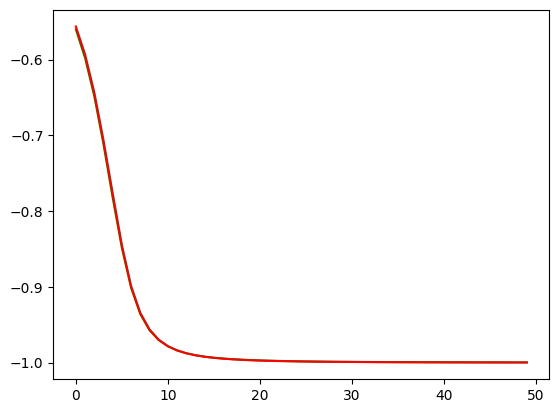

In [117]:
plt.plot(range(len(losses_D)), losses_D, color='green')
plt.plot(range(len(losses_G)), losses_G, color='red')
plt.show()

In [118]:
scores = []

with torch.no_grad():
    for hist in dataloader:
        #hist = torch.tensor(hist, dtype=float)
        hist = hist.unsqueeze(1)
        score = 1 - disc(hist)
        for s in score:
            scores.append(s)       

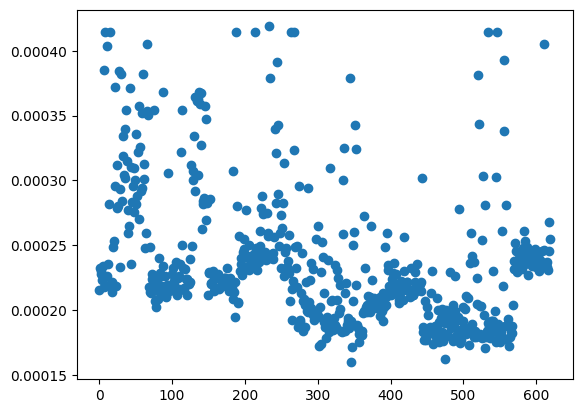

In [119]:
plt.scatter(range(len(scores)), scores)

In [83]:
scores.index(max(scores))

135

NameError: name 'outliers' is not defined

NameError: name 'outliers' is not defined